# Insurance Claims & Portfolio Risk Analytics
## StudyBuild - Project 01 | Python + Tableau

**Business Scenario:** We have joined the analytics team of a motor-insurance company. Management wants a clear view of the portfolio: where claims occur most frequently, where claim costs are highest, which policy segments deserve closer attention, and which patterns should be monitored in the next reporting cycle.

**Dataset:** French Motor Third-Party Liability (freMTPL2) — 677,991+ motor liability policies observed mainly during 2011-2013.

**Important:** freMTPL2 does **not** include written premium(all the money the custumer pays). Therefore, **Loss Ratio must not** be calculated. We use **claim frequency**, **claim severity**, and **total claim cost** as core insurance KPIs.

## Table of Contents

1. **Data Loading & Inspection**
2. **Data Quality Checks & Cleaning**
3. **Merge the two data sets & Feature Engineering**
4. **Q1 — Portfolio Health Summary**
5. **Q2 — Regional Claim Burden Analysis**
6. **Q3 — Driver & Vehicle Segment Patterns**
7. **Q4 — Frequency vs. Severity Scatter**
8. **Q5 — Pareto / Claim Cost Concentration**
9. **Q6 — Unusual Claims & Outlier Investigation**
10. **Q7 — Executive Dashboard Design**
11. **Q8 — Three Data-Driven Recommendations**


run the cells one after another in order

---
## 1. Setup & Data Loading

In this step we want to get to know the data and be familiar with it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Imports tools for controlling how numbers appear on chart axes.
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# colors
RED = '\033[91m'
RESET = '\033[0m'

# default chart appearance
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# all the paths relatively
RAW_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
FIG_DIR = Path('../figures')
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
freq = pd.read_csv(RAW_DIR / 'freMTPL2freq.csv')
sev = pd.read_csv(RAW_DIR / 'freMTPL2sev.csv')

print(f'Frequency table shape: {freq.shape}')
print(f'Severity table shape:  {sev.shape}')
print()
print('=== Frequency columns ===')
print(freq.dtypes)
print()
print('=== Severity columns ===')
print(sev.dtypes)

Frequency table shape: (678013, 12)
Severity table shape:  (26639, 2)

=== Frequency columns ===
IDpol         float64
ClaimNb         int64
Exposure      float64
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand          str
VehGas            str
Area              str
Density         int64
Region            str
dtype: object

=== Severity columns ===
IDpol            int64
ClaimAmount    float64
dtype: object


In [3]:
freq.head(10)

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine
5,13.0,1,0.52,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais
6,15.0,1,0.45,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais
7,17.0,1,0.27,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon
8,18.0,1,0.71,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon
9,21.0,1,0.15,7,0,41,50,B12,Diesel,B,60,Pays-de-la-Loire


In [4]:
freq.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [5]:
sev.head(10)

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00
5,4073956,1204.00
6,4012173,1204.00
7,4020812,54942.62
8,4020812,7620.00
9,4074074,1204.00


In [6]:
sev.describe().T

,count,mean,std,min,25%,50%,75%,max
IDpol,26639.0,2.279864e+06,1.577202e+06,139.0,1087642.50,2137413.0,3180162.00,6113971.00
ClaimAmount,26639.0,2.278536e+03,2.929748e+04,1.0,686.81,1172.0,1228.08,4075400.56


---
## 2. Data Quality Checks & Cleaning

similar to study builds first project we want to clean the data.

In [7]:
print(f'{RED}=== SEVERITY TABLE ==={RESET}')
print(f'Unique policy IDs with claims: {sev["IDpol"].nunique():,} / {len(sev):,} rows')
print(f'ClaimAmount <= 0: {(sev["ClaimAmount"] <= 0).sum()}')
print()
print(sev['ClaimAmount'].describe())
print()

for p in [1, 10, 50, 90, 95, 99, 99.9]:
    print(f"  {p}'th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f} --> the 1% cheapest claims are at maximum 40 eurors" if p == 1 else f"  {p}'th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f}")

=== SEVERITY TABLE ===
Unique policy IDs with claims: 24,950 / 26,639 rows
ClaimAmount <= 0: 0

count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

  1'th percentile: 40 --> the 1% cheapest claims are at maximum 40 eurors
  10'th percentile: 197
  50'th percentile: 1,172
  90'th percentile: 2,799
  95'th percentile: 4,862
  99'th percentile: 16,794
  99.9'th percentile: 162,784


In [8]:
# --- Severity table quality ---
print(f'{RED}=== SEVERITY TABLE ==={RESET}')
print(f'Unique policy IDs with claims: {sev["IDpol"].nunique():,} / {len(sev):,} rows')
print(f'Missing ClaimAmount: {sev["ClaimAmount"].isnull().sum()}')
print(f'ClaimAmount <= 0: {(sev["ClaimAmount"] <= 0).sum()}')
print()
print(f'{RED}ClaimAmount distribution:{RESET}')
print(sev['ClaimAmount'].describe().T)
print()
# Percentiles for severity
for p in [1, 10, 50, 90, 95, 99, 99.9]:
    print(f'  {p}th percentile: {sev["ClaimAmount"].quantile(p/100):,.0f}')

=== SEVERITY TABLE ===
Unique policy IDs with claims: 24,950 / 26,639 rows
Missing ClaimAmount: 0
ClaimAmount <= 0: 0

ClaimAmount distribution:
count    2.663900e+04
mean     2.278536e+03
std      2.929748e+04
min      1.000000e+00
25%      6.868100e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: ClaimAmount, dtype: float64

  1th percentile: 40
  10th percentile: 197
  50th percentile: 1,172
  90th percentile: 2,799
  95th percentile: 4,862
  99th percentile: 16,794
  99.9th percentile: 162,784


In [9]:
before = len(freq)
freq = freq[freq['Exposure'] > 0].copy()
print(f'Removed {before - len(freq)} policies with Exposure <= 0')

before = len(freq)
freq = freq[freq['ClaimNb'] >= 0].copy()
print(f'Removed {before - len(freq)} policies with ClaimNb < 0')

print(f'\nExposure range after cleaning: [{freq["Exposure"].min():.4f}, {freq["Exposure"].max():.4f}]')

print(f'\nClaimNb distribution:')
print(freq['ClaimNb'].value_counts().sort_index())

print(f'\nCleaned frequency shape: {freq.shape}')

Removed 0 policies with Exposure <= 0
Removed 0 policies with ClaimNb < 0

Exposure range after cleaning: [0.0027, 2.0100]

ClaimNb distribution:
ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

Cleaned frequency shape: (678013, 12)


**The original data set is already clean**

In [10]:
print(sev.shape)
before = len(sev)
sev = sev[sev['ClaimAmount'] > 0].copy()
print(f'Removed {before - len(sev)} rows with ClaimAmount <= 0')

print(f'Missing IDpol in severity: {sev["IDpol"].isnull().sum()}')

print(f'\nCleaned severity shape: {sev.shape}')

(26639, 2)
Removed 0 rows with ClaimAmount <= 0
Missing IDpol in severity: 0

Cleaned severity shape: (26639, 2)




---
## 3. Merge & Feature Engineering

**Merge Logic:** The frequency table contains **policy-level** information (one row per policy with claim count and exposure). The severity table contains **claim-level** information (one row per individual claim with its amount). We aggregate severity data to the policy level by summing ClaimAmount per policy, then merge with the frequency table on `IDpol`.

Note: Not all policies have claims in the severity table. We use a **left merge** from frequency to preserve all policies.

In [11]:
sev_agg = sev.groupby('IDpol').agg(
    TotalClaimCost=('ClaimAmount', 'sum'),
    NumClaimsInSev=('ClaimAmount', 'count'),
    MaxClaimAmount=('ClaimAmount', 'max'),
    MeanClaimAmount=('ClaimAmount', 'mean'),
).reset_index()

print(f'Severity aggregated to {len(sev_agg):,} unique policies')
print(f'Policies in freq table: {len(freq):,}')
print(f'Policies with claims in severity: {len(sev_agg):,}')
print(f'Policies without severity data: {len(freq) - sev_agg["IDpol"].isin(freq["IDpol"]).sum():,}')

df = freq.merge(sev_agg, on='IDpol', how='left')

df['TotalClaimCost'] = df['TotalClaimCost'].fillna(0)
df['NumClaimsInSev'] = df['NumClaimsInSev'].fillna(0)
df['MaxClaimAmount'] = df['MaxClaimAmount'].fillna(0)
df['MeanClaimAmount'] = df['MeanClaimAmount'].fillna(0)

print(f'\nMerged dataset shape: {df.shape}')
print(f'Policies with total claim cost > 0: {(df["TotalClaimCost"] > 0).sum():,}')

Severity aggregated to 24,950 unique policies
Policies in freq table: 678,013
Policies with claims in severity: 24,950
Policies without severity data: 653,069

Merged dataset shape: (678013, 16)
Policies with total claim cost > 0: 24,944


*I want to feature engineer and implement different age groups to simplify the tableau process*

In [12]:
df['DrivAgeGroup'] = pd.cut(
    df['DrivAge'],
    bins=[17, 25, 35, 45, 55, 65, 101],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    right=True
)

df['VehAgeGroup'] = pd.cut(
    df['VehAge'],
    bins=[-1, 0, 2, 5, 10, 101],
    labels=['New (0)', '1-2', '3-5', '6-10', '11+'],
    right=True
)

df['VehPowerGroup'] = pd.cut(
    df['VehPower'],
    bins=[0, 5, 7, 9, 11, 16],
    labels=['4-5', '6-7', '8-9', '10-11', '12-15'],
    right=True
)

df['BonusMalusCat'] = pd.cut(
    df['BonusMalus'],
    bins=[0, 50, 75, 100, 150, 231],
    labels=['50 (Best)', '51-75', '76-100', '101-150', '151+ (Worst)'],
    right=True
)

df['DensityGroup'] = pd.cut(
    df['Density'],
    bins=[0, 100, 500, 2000, 30000],
    labels=['Rural (<100)', 'Suburban (100-500)', 'Urban (500-2000)', 'Metro (>2000)'],
    right=True
)

---
## 4. Q1 — What is the overall health of the insurance portfolio?

**KPI Definitions:**
- **Policy Count** = number of unique policies
- **Total Exposure** = sum of policy exposure in years
- **Claim Count** = total number of claims
- **Claim Frequency** = Claim Count / Exposure (adjusts for differing exposure periods)
- **Total Claim Cost** = sum of ClaimAmount
- **Average Claim Severity** = Total Claim Cost / Number of observed claims (denominator = row count of severity table, i.e. 26,639 individual claims)

> **Aggregation note:** The severity table contains one row per individual claim. Some policies appear multiple times (if they had multiple claims). We aggregate by summing ClaimAmount per policy, and the denominator for average severity is the **total number of individual claim records** (26,639), not the number of policies with claims (34,060). This ensures the metric represents average cost **per observed claim**.

**Why raw claim counts are misleading:** A region or segment with more policies and/or longer exposure periods will naturally accumulate more claims, even if the underlying risk is the same. Claim frequency (claims per unit of exposure) is the appropriate metric for comparing claim occurrence.

In [13]:
policy_count = df['IDpol'].nunique()
total_exposure = df['Exposure'].sum()
total_claims = df['ClaimNb'].sum()
total_claim_cost = df['TotalClaimCost'].sum()
policies_with_claims = (df['ClaimNb'] > 0).sum()
num_individual_claims = len(sev)

claim_frequency = total_claims / total_exposure
avg_severity = total_claim_cost / num_individual_claims
cost_per_exposure = total_claim_cost / total_exposure

print("Portfolio Health Summary")
print(f"Policies: {policy_count:,}")
print(f"Exposure: {total_exposure:,.1f} years")
print(f"Claims: {total_claims:,}")
print(f"Policies with claims: {policies_with_claims:,} ({policies_with_claims / policy_count:.1%})")
print(f"Claim frequency: {claim_frequency:.4f}")
print(f"Total claim cost: €{total_claim_cost:,.0f}")
print(f"Average claim severity: €{avg_severity:,.0f}")
print(f"Cost per exposure year: €{cost_per_exposure:,.0f}")

Portfolio Health Summary
Policies: 678,013
Exposure: 358,499.4 years
Claims: 36,102
Policies with claims: 34,060 (5.0%)
Claim frequency: 0.1007
Total claim cost: €59,909,216
Average claim severity: €2,249
Cost per exposure year: €167


---
## 5. Q2 — Which regions generate the greatest claim burden?

We compare regions using **exposure**, **claim frequency**, **total claim cost**, and **average severity**. We do NOT rank regions only by total claim count.

In [14]:
region_kpi = df.groupby('Region').agg(
    PolicyCount=('IDpol', 'count'),
    TotalExposure=('Exposure', 'sum'),
    TotalClaims=('ClaimNb', 'sum'),
    TotalClaimCost=('TotalClaimCost', 'sum'),
    PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum()),
).reset_index()

region_kpi['ClaimFrequency'] = region_kpi['TotalClaims'] / region_kpi['TotalExposure']
region_kpi['AvgSeverity'] = region_kpi['TotalClaimCost'] / region_kpi['PoliciesWithClaims']
region_kpi['CostPerExposure'] = region_kpi['TotalClaimCost'] / region_kpi['TotalExposure']

# Sort by claim frequency
region_kpi = region_kpi.sort_values('ClaimFrequency', ascending=False).reset_index(drop=True)

print('=== REGIONAL CLAIM BURDEN (sorted by Claim Frequency) ===')
print(region_kpi[['Region', 'PolicyCount', 'TotalExposure', 'ClaimFrequency',
                  'TotalClaimCost', 'AvgSeverity', 'CostPerExposure']].to_string(index=False, float_format='{:,.2f}'.format))

=== REGIONAL CLAIM BURDEN (sorted by Claim Frequency) ===
                     Region  PolicyCount  TotalExposure  ClaimFrequency  TotalClaimCost  AvgSeverity  CostPerExposure
                      Corse         4516       1,765.94            0.14      464,582.55     2,111.74           263.08
          Champagne-Ardenne         3026       1,205.83            0.13      481,248.34     3,229.85           399.10
              Ile-de-France        69791      30,208.64            0.13    4,563,221.86     1,228.99           151.06
                   Picardie         7994       3,574.41            0.12      687,624.87     1,633.31           192.37
                Rhone-Alpes        84752      45,347.42            0.11   10,278,303.85     2,159.31           226.66
                     Alsace         2200       1,209.12            0.11      121,424.99       979.23           100.42
Provence-Alpes-Cotes-D'Azur        79315      35,790.32            0.11    6,871,024.80     1,895.46           191.9

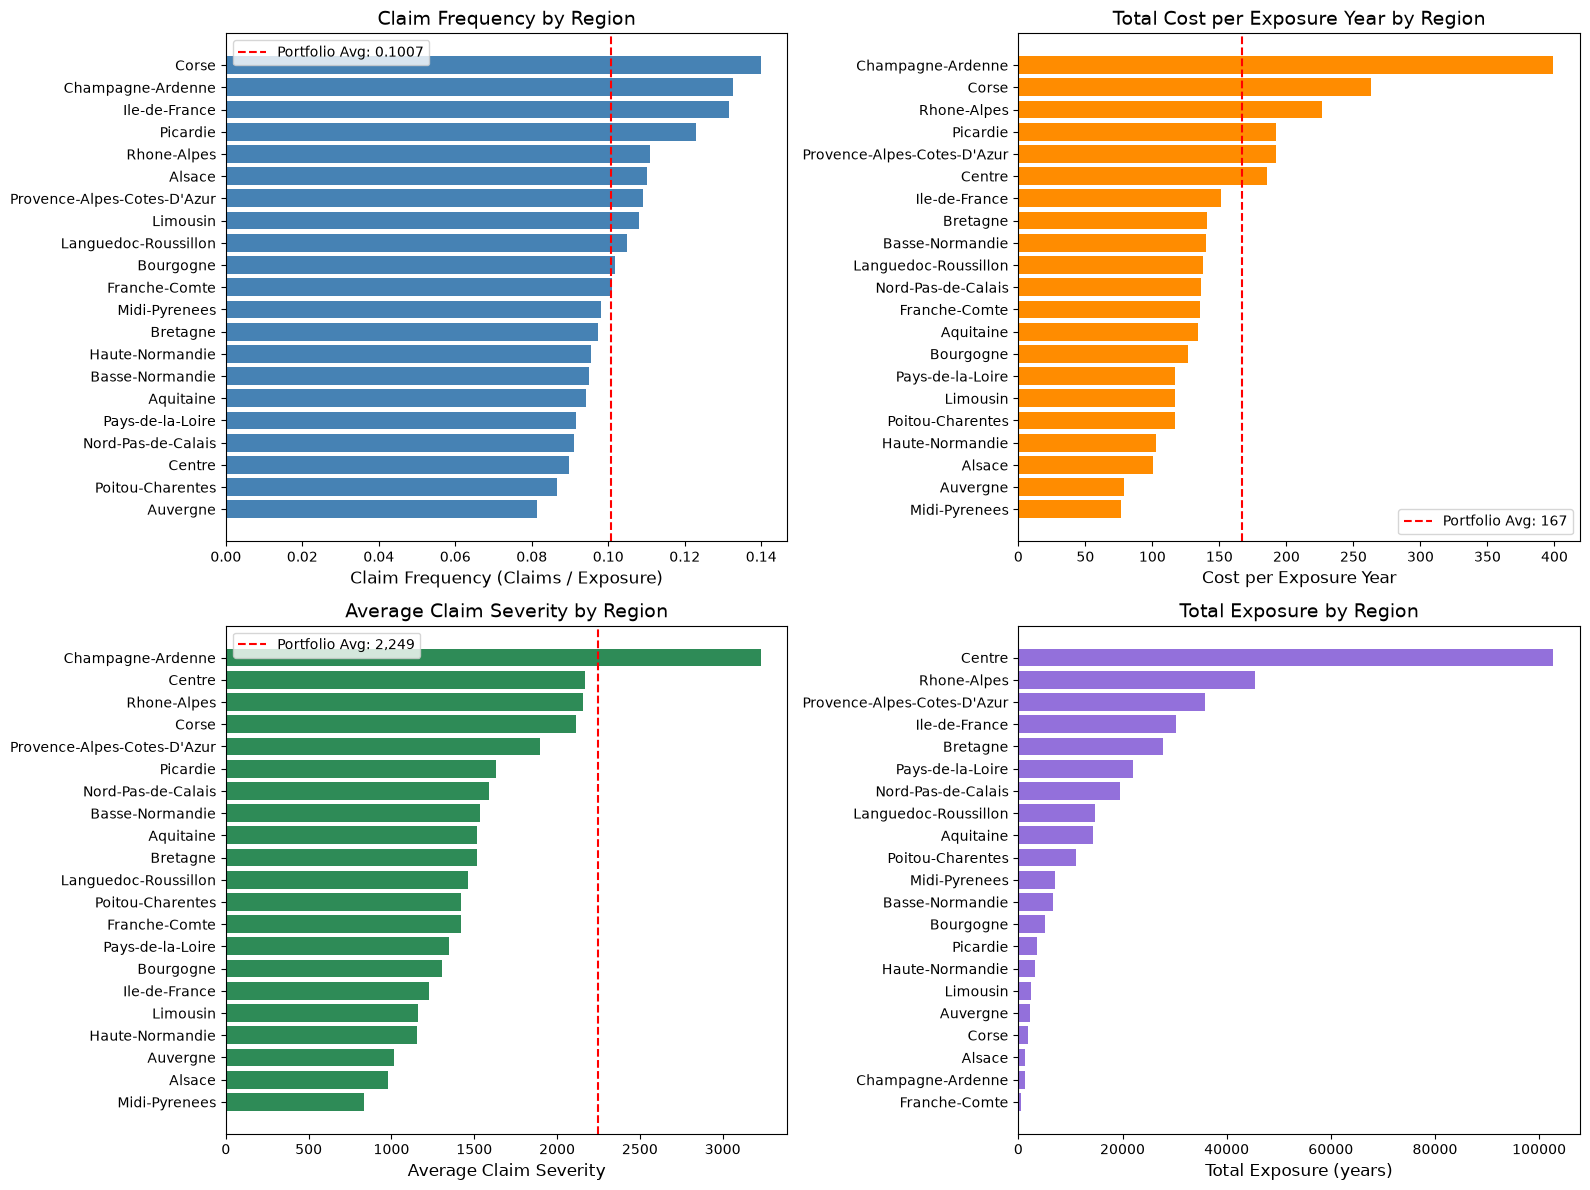

Figure saved: figures/q2_regional_comparison.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

r_sorted_freq = region_kpi.sort_values('ClaimFrequency', ascending=True)
r_sorted_cost = region_kpi.sort_values('CostPerExposure', ascending=True)
r_sorted_sev = region_kpi.sort_values('AvgSeverity', ascending=True)

axes[0, 0].barh(r_sorted_freq['Region'], r_sorted_freq['ClaimFrequency'], color='steelblue')
axes[0, 0].set_xlabel('Claim Frequency (Claims / Exposure)')
axes[0, 0].set_title('Claim Frequency by Region')
axes[0, 0].axvline(x=claim_frequency, color='red', linestyle='--', label=f'Portfolio Avg: {claim_frequency:.4f}')
axes[0, 0].legend()

axes[0, 1].barh(r_sorted_cost['Region'], r_sorted_cost['CostPerExposure'], color='darkorange')
axes[0, 1].set_xlabel('Cost per Exposure Year')
axes[0, 1].set_title('Total Cost per Exposure Year by Region')
axes[0, 1].axvline(x=cost_per_exposure, color='red', linestyle='--',
                    label=f'Portfolio Avg: {cost_per_exposure:,.0f}')
axes[0, 1].legend()

axes[1, 0].barh(r_sorted_sev['Region'], r_sorted_sev['AvgSeverity'], color='seagreen')
axes[1, 0].set_xlabel('Average Claim Severity')
axes[1, 0].set_title('Average Claim Severity by Region')
axes[1, 0].axvline(x=avg_severity, color='red', linestyle='--',
                    label=f'Portfolio Avg: {avg_severity:,.0f}')
axes[1, 0].legend()

r_sorted_exp = region_kpi.sort_values('TotalExposure', ascending=True)
axes[1, 1].barh(r_sorted_exp['Region'], r_sorted_exp['TotalExposure'], color='mediumpurple')
axes[1, 1].set_xlabel('Total Exposure (years)')
axes[1, 1].set_title('Total Exposure by Region')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_regional_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q2_regional_comparison.png')

In [31]:
region = region_kpi.loc[region_kpi['CostPerExposure'].idxmax()]

print(f"Region to watch: {region['Region']}")
print(f"Claim frequency: {region['ClaimFrequency']:.4f}")
print(f"Average severity: €{region['AvgSeverity']:,.0f}")
print(f"Cost per exposure: €{region['CostPerExposure']:,.0f}")

Region to watch: Champagne-Ardenne
Claim frequency: 0.1327
Average severity: €3,230
Cost per exposure: €399


---
## 6. Q3 — Which driver and vehicle segments show different claim patterns?

We create sensible groups and compare **claim frequency** and **severity** across driver age, vehicle age, vehicle power, fuel type, and bonus-malus categories.

In [32]:
def segment_analysis(data, group_col):
    result = data.groupby(group_col, observed=True).agg(
        PolicyCount=('IDpol', 'count'),
        TotalExposure=('Exposure', 'sum'),
        TotalClaims=('ClaimNb', 'sum'),
        TotalClaimCost=('TotalClaimCost', 'sum'),
        PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum())
    )

    result['ClaimFrequency'] = result['TotalClaims'] / result['TotalExposure']
    result['AvgSeverity'] = result['TotalClaimCost'] / result['PoliciesWithClaims'].replace(0, np.nan)
    result['CostPerExposure'] = result['TotalClaimCost'] / result['TotalExposure']

    return result.reset_index()


groups = {
    'Driver Age': 'DrivAgeGroup',
    'Vehicle Age': 'VehAgeGroup',
    'Vehicle Power': 'VehPowerGroup',
    'Fuel Type': 'VehGas',
    'Bonus-Malus': 'BonusMalusCat'
}

for name, column in groups.items():
    result = segment_analysis(df, column)
    print(f"\n=== {name} ===")
    print(result[[column, 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(index=False))


=== Driver Age ===
DrivAgeGroup  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
       18-25        38895        0.175069  4692.055486       758.401214
       26-35       149183        0.096179  1682.888910       153.136166
       36-45       170352        0.095744  1520.197170       138.183455
       46-55       161899        0.103687  1413.913087       138.082931
       56-65        90691        0.091704  1398.085128       121.053571
         66+        66993        0.094853  1585.858218       141.930735

=== Vehicle Age ===
VehAgeGroup  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
    New (0)        57739        0.311322   476.415567       140.254405
        1-2       130408        0.091247  1868.032449       159.385508
        3-5       132490        0.093601  1661.350634       146.486412
       6-10       171594        0.099446  1698.374368       159.632813
        11+       185782        0.079511  2607.236297       196.275323

=== Vehicle Power ===
VehPow

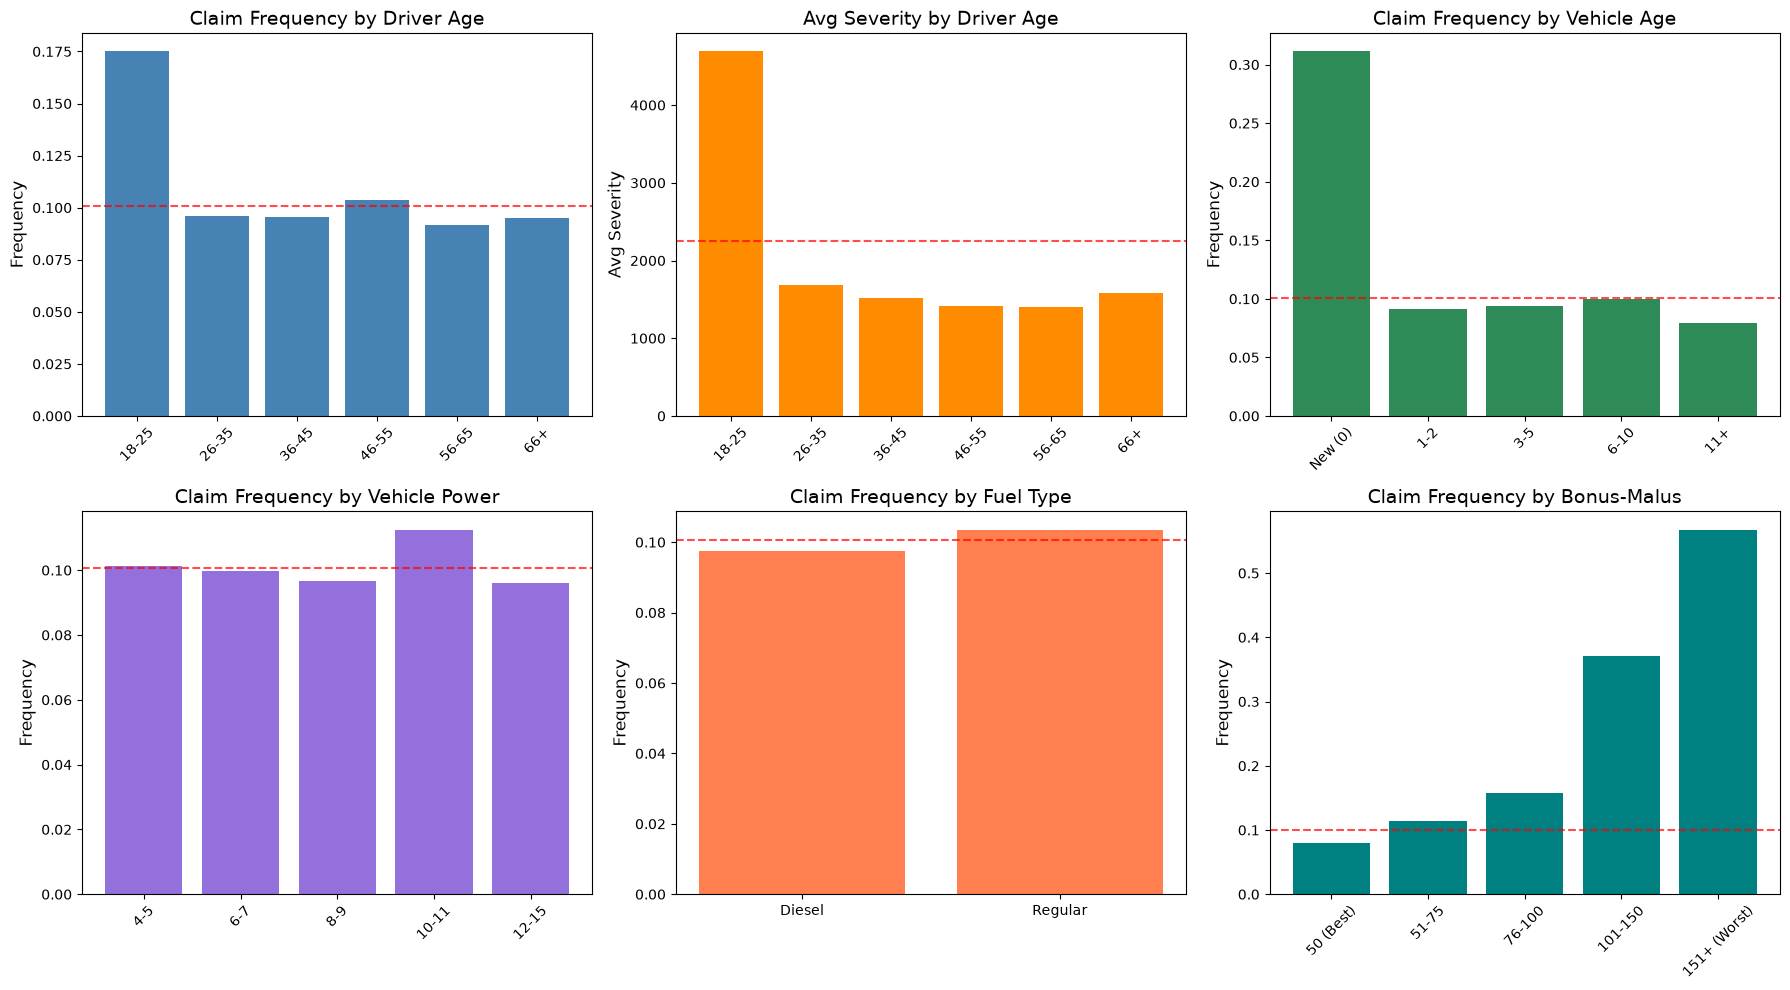

Figure saved: figures/q3_segment_patterns.png


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


axes[0, 0].bar(age_kpi['DrivAgeGroup'].astype(str), age_kpi['ClaimFrequency'], color='steelblue')
axes[0, 0].set_title('Claim Frequency by Driver Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

axes[0, 1].bar(age_kpi['DrivAgeGroup'].astype(str), age_kpi['AvgSeverity'], color='darkorange')
axes[0, 1].set_title('Avg Severity by Driver Age')
axes[0, 1].set_ylabel('Avg Severity')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=avg_severity, color='red', linestyle='--', alpha=0.7)

axes[0, 2].bar(vehage_kpi['VehAgeGroup'].astype(str), vehage_kpi['ClaimFrequency'], color='seagreen')
axes[0, 2].set_title('Claim Frequency by Vehicle Age')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

axes[1, 0].bar(vehpow_kpi['VehPowerGroup'].astype(str), vehpow_kpi['ClaimFrequency'], color='mediumpurple')
axes[1, 0].set_title('Claim Frequency by Vehicle Power')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

axes[1, 1].bar(fuel_kpi['VehGas'], fuel_kpi['ClaimFrequency'], color='coral')
axes[1, 1].set_title('Claim Frequency by Fuel Type')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

axes[1, 2].bar(bm_kpi['BonusMalusCat'].astype(str), bm_kpi['ClaimFrequency'], color='teal')
axes[1, 2].set_title('Claim Frequency by Bonus-Malus')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].axhline(y=claim_frequency, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_segment_patterns.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q3_segment_patterns.png')

In [34]:
print('=== KEY FINDINGS FROM SEGMENT ANALYSIS ===')
print()

highest_freq_driver = age_kpi.loc[age_kpi['ClaimFrequency'].idxmax()]
print(f'1. HIGHEST FREQUENCY DRIVER AGE: {highest_freq_driver["DrivAgeGroup"]}')
print(f'   Frequency: {highest_freq_driver["ClaimFrequency"]:.4f}')
print(f'   (Young/inexperienced drivers claim more often per unit of exposure)')
print()

highest_sev_driver = age_kpi.loc[age_kpi['AvgSeverity'].idxmax()]
print(f'2. HIGHEST SEVERITY DRIVER AGE: {highest_sev_driver["DrivAgeGroup"]}')
print(f'   Avg Severity: {highest_sev_driver["AvgSeverity"]:,.0f}')
print(f'   (When these drivers claim, each claim costs more on average)')
print()

print('3. VEHICLE AGE PATTERN:')
for _, row in vehage_kpi.iterrows():
    print(f'   {row["VehAgeGroup"]}: freq={row["ClaimFrequency"]:.4f}, sev={row["AvgSeverity"]:,.0f}')
print('   (New vehicles may have different claim patterns than older ones)')
print()

print('4. BONUS-MALUS PATTERN:')
for _, row in bm_kpi.iterrows():
    print(f'   {row["BonusMalusCat"]}: freq={row["ClaimFrequency"]:.4f}, policies={row["PolicyCount"]:,}')
print('   (Higher BM scores correlate with higher claim frequency)')
print()

print('Note: These are descriptive associations. We cannot establish causation')
print('from this observational dataset alone.')

=== KEY FINDINGS FROM SEGMENT ANALYSIS ===

1. HIGHEST FREQUENCY DRIVER AGE: 18-25
   Frequency: 0.1751
   (Young/inexperienced drivers claim more often per unit of exposure)

2. HIGHEST SEVERITY DRIVER AGE: 18-25
   Avg Severity: 4,692
   (When these drivers claim, each claim costs more on average)

3. VEHICLE AGE PATTERN:
   New (0): freq=0.3113, sev=476
   1-2: freq=0.0912, sev=1,868
   3-5: freq=0.0936, sev=1,661
   6-10: freq=0.0994, sev=1,698
   11+: freq=0.0795, sev=2,607
   (New vehicles may have different claim patterns than older ones)

4. BONUS-MALUS PATTERN:
   50 (Best): freq=0.0802, policies=384,156
   51-75: freq=0.1133, policies=175,012
   76-100: freq=0.1582, policies=111,051
   101-150: freq=0.3705, policies=7,585
   151+ (Worst): freq=0.5677, policies=209
   (Higher BM scores correlate with higher claim frequency)

Note: These are descriptive associations. We cannot establish causation
from this observational dataset alone.


---
## 7. Q4 — Are frequent-claim segments also expensive-claim segments?

We compare claim frequency against average severity at the segment level using a **scatter plot / quadrant view**.

In [20]:
segment_cols = ['Region']
seg_analysis = df.groupby(segment_cols, observed=True).agg(
    PolicyCount=('IDpol', 'count'),
    TotalExposure=('Exposure', 'sum'),
    TotalClaims=('ClaimNb', 'sum'),
    TotalClaimCost=('TotalClaimCost', 'sum'),
    PoliciesWithClaims=('ClaimNb', lambda x: (x > 0).sum()),
).reset_index()

seg_analysis['ClaimFrequency'] = seg_analysis['TotalClaims'] / seg_analysis['TotalExposure']
seg_analysis['AvgSeverity'] = seg_analysis['TotalClaimCost'] / seg_analysis['PoliciesWithClaims'].replace(0, np.nan)
seg_analysis['CostPerExposure'] = seg_analysis['TotalClaimCost'] / seg_analysis['TotalExposure']

freq_median = seg_analysis['ClaimFrequency'].median()
sev_median = seg_analysis['AvgSeverity'].median()

print('=== FREQUENCY vs SEVERITY QUADRANT ANALYSIS ===')
print(f'Frequency median: {freq_median:.4f}')
print(f'Severity median:  {sev_median:,.0f}')
print()

def assign_quadrant(row):
    if row['ClaimFrequency'] >= freq_median and row['AvgSeverity'] >= sev_median:
        return 'HIGH Freq / HIGH Sev'
    elif row['ClaimFrequency'] >= freq_median and row['AvgSeverity'] < sev_median:
        return 'HIGH Freq / LOW Sev'
    elif row['ClaimFrequency'] < freq_median and row['AvgSeverity'] >= sev_median:
        return 'LOW Freq / HIGH Sev'
    else:
        return 'LOW Freq / LOW Sev'

seg_analysis['Quadrant'] = seg_analysis.apply(assign_quadrant, axis=1)

high_high = seg_analysis[seg_analysis['Quadrant'] == 'HIGH Freq / HIGH Sev'].sort_values('CostPerExposure', ascending=False)
print('Segments in HIGH Frequency / HIGH Severity quadrant:')
print(high_high[['Region', 'PolicyCount', 'ClaimFrequency', 'AvgSeverity', 'CostPerExposure']].to_string(
    index=False, float_format='{:,.2f}'.format))
print()

print('Segments per quadrant:')
print(seg_analysis['Quadrant'].value_counts().to_string())

=== FREQUENCY vs SEVERITY QUADRANT ANALYSIS ===
Frequency median: 0.1011
Severity median:  1,462

Segments in HIGH Frequency / HIGH Severity quadrant:
                     Region  PolicyCount  ClaimFrequency  AvgSeverity  CostPerExposure
          Champagne-Ardenne         3026            0.13     3,229.85           399.10
                      Corse         4516            0.14     2,111.74           263.08
                Rhone-Alpes        84752            0.11     2,159.31           226.66
                   Picardie         7994            0.12     1,633.31           192.37
Provence-Alpes-Cotes-D'Azur        79315            0.11     1,895.46           191.98
       Languedoc-Roussillon        35805            0.10     1,462.14           137.82

Segments per quadrant:
Quadrant
HIGH Freq / HIGH Sev    6
HIGH Freq / LOW Sev     5
LOW Freq / HIGH Sev     5
LOW Freq / LOW Sev      5


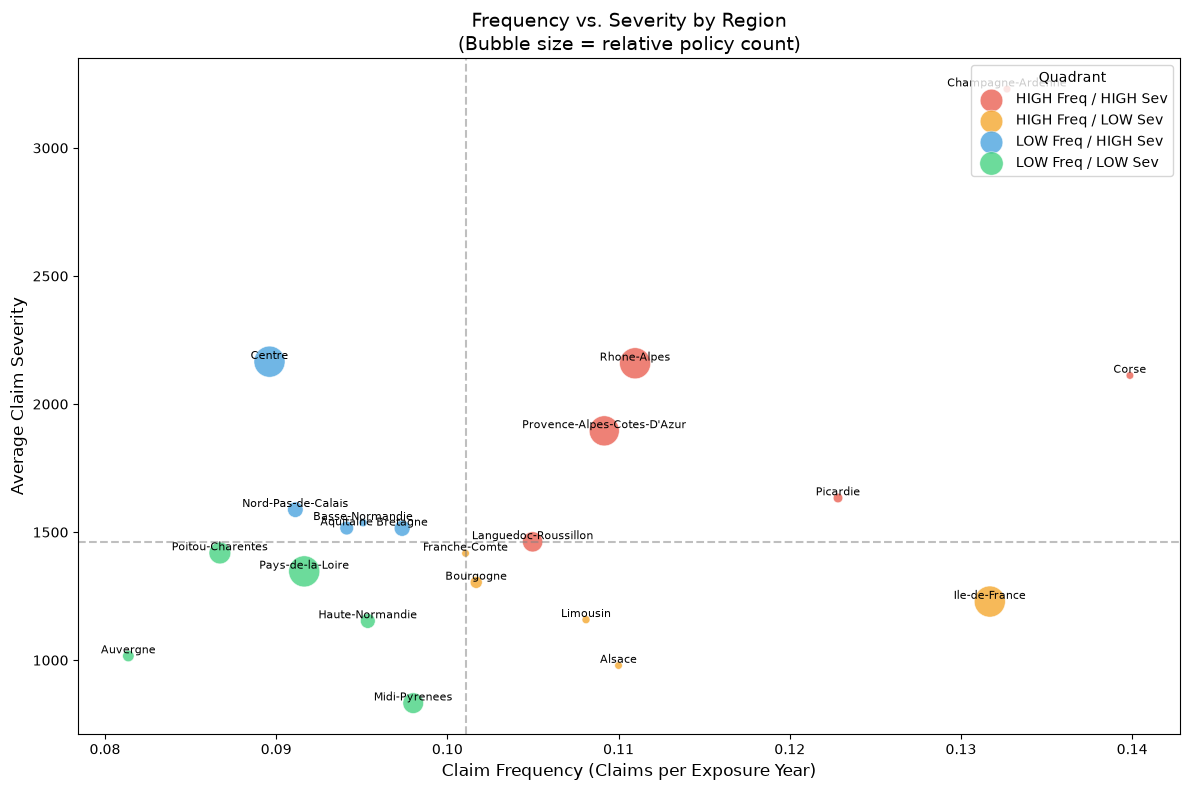

Figure saved: figures/q4_frequency_vs_severity.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = {
    'HIGH Freq / HIGH Sev': '#e74c3c',
    'HIGH Freq / LOW Sev': '#f39c12',
    'LOW Freq / HIGH Sev': '#3498db',
    'LOW Freq / LOW Sev': '#2ecc71',
}

for quad, color in colors.items():
    mask = seg_analysis['Quadrant'] == quad
    subset = seg_analysis[mask]
    sizes = np.clip(subset['PolicyCount'] / subset['PolicyCount'].max() * 500, 30, 500)
    ax.scatter(subset['ClaimFrequency'], subset['AvgSeverity'],
               s=sizes, c=color, alpha=0.7, edgecolors='white', linewidth=0.5,
               label=quad)
    # Label each region
    for _, row in subset.iterrows():
        ax.annotate(row['Region'], (row['ClaimFrequency'], row['AvgSeverity']),
                    fontsize=8, ha='center', va='bottom')

ax.axvline(x=freq_median, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=sev_median, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Claim Frequency (Claims per Exposure Year)')
ax.set_ylabel('Average Claim Severity')
ax.set_title('Frequency vs. Severity by Region\n(Bubble size = relative policy count)')
ax.legend(title='Quadrant', loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q4_frequency_vs_severity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q4_frequency_vs_severity.png')

---
## 8. Q5 — Is claim cost concentrated in a small number of claims or policies?

We perform a **Pareto-style analysis** of ClaimAmount to understand cost concentration.

In [22]:
claims = sev.copy()
claims = claims.sort_values('ClaimAmount', ascending=False).reset_index(drop=True)
claims['CumCost'] = claims['ClaimAmount'].cumsum()
claims['CumCostPct'] = claims['CumCost'] / claims['ClaimAmount'].sum() * 100
claims['ClaimRank'] = np.arange(1, len(claims) + 1)
claims['ClaimRankPct'] = claims['ClaimRank'] / len(claims) * 100

total_cost_sev = claims['ClaimAmount'].sum()
total_claims_sev = len(claims)

for pct in [1, 5, 10, 20, 50]:
    n_claims = int(total_claims_sev * pct / 100)
    cost_share = claims.head(n_claims)['ClaimAmount'].sum() / total_cost_sev * 100
    print(f'Top {pct:>3}% of claims ({n_claims:>5,} claims) account for {cost_share:>5.1f}% of total cost')

print()
print(f'Total individual claims: {total_claims_sev:,}')
print(f'Total claim cost:        {total_cost_sev:,.0f}')

policy_cost = df[df['TotalClaimCost'] > 0].sort_values('TotalClaimCost', ascending=False)
total_policies_with_cost = len(policy_cost)
cum_cost_policy = policy_cost['TotalClaimCost'].cumsum()
cum_cost_pct_policy = cum_cost_policy / policy_cost['TotalClaimCost'].sum() * 100

for pct in [1, 5, 10, 20, 50]:
    n_policies = int(total_policies_with_cost * pct / 100)
    cost_share = policy_cost.head(n_policies)['TotalClaimCost'].sum() / policy_cost['TotalClaimCost'].sum() * 100
    print(f'Top {pct:>3}% of policies ({n_policies:>5,} policies) account for {cost_share:>5.1f}% of total cost')

Top   1% of claims (  266 claims) account for  37.9% of total cost
Top   5% of claims (1,331 claims) account for  52.1% of total cost
Top  10% of claims (2,663 claims) account for  60.0% of total cost
Top  20% of claims (5,327 claims) account for  68.9% of total cost
Top  50% of claims (13,319 claims) account for  85.0% of total cost

Total individual claims: 26,639
Total claim cost:        60,697,931
Top   1% of policies (  249 policies) account for  37.9% of total cost
Top   5% of policies (1,247 policies) account for  52.3% of total cost
Top  10% of policies (2,494 policies) account for  60.2% of total cost
Top  20% of policies (4,988 policies) account for  69.6% of total cost
Top  50% of policies (12,472 policies) account for  85.3% of total cost


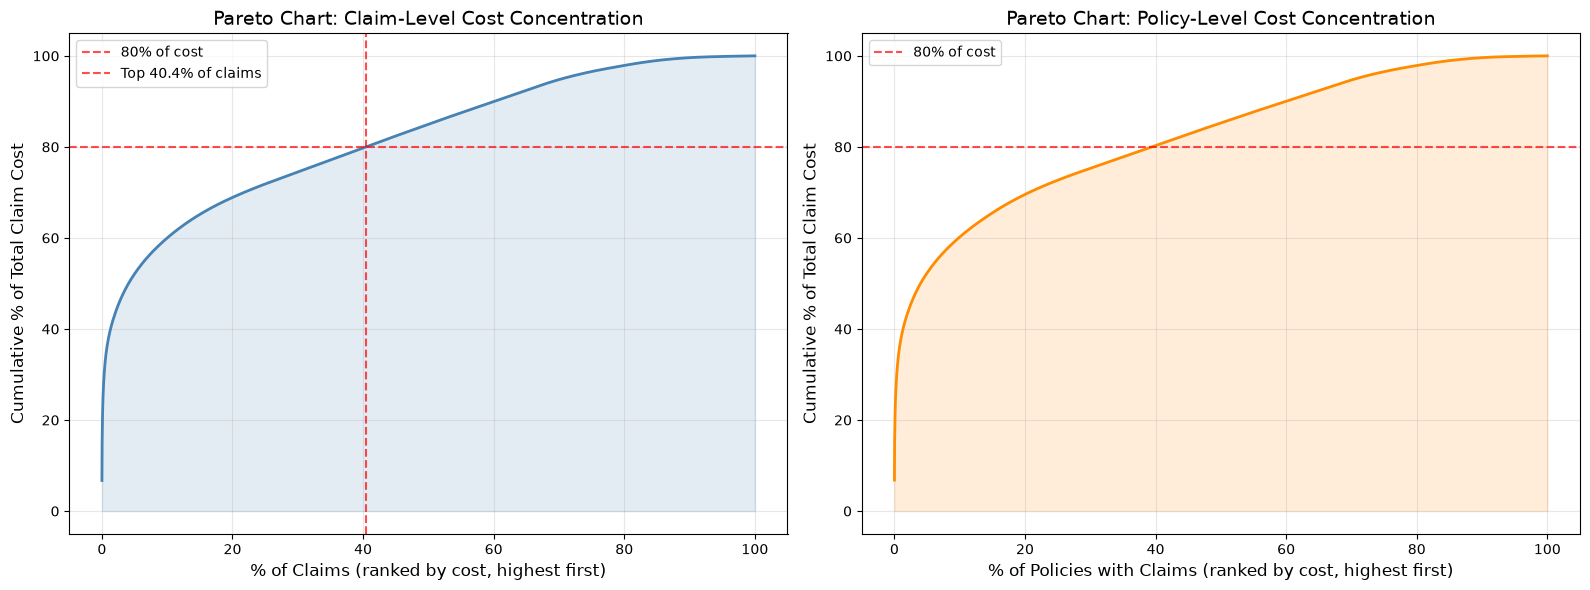

Figure saved: figures/q5_pareto_analysis.png

Business implication:
  A small proportion of high-cost claims/policies accounts for a
  disproportionate share of total claim cost. This means:
  - Targeted review of the most expensive claims can have outsized impact
  - Claims management resources should focus on high-cost tail claims
  - The Pareto principle (80/20 rule) often applies in insurance


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(claims['ClaimRankPct'], claims['CumCostPct'], color='steelblue', linewidth=2)
ax1.fill_between(claims['ClaimRankPct'], claims['CumCostPct'], alpha=0.15, color='steelblue')
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of cost')
ax1.axvline(x=claims[claims['CumCostPct'] >= 80]['ClaimRankPct'].iloc[0],
            color='red', linestyle='--', alpha=0.7,
            label=f'Top {claims[claims["CumCostPct"] >= 80]["ClaimRankPct"].iloc[0]:.1f}% of claims')
ax1.set_xlabel('% of Claims (ranked by cost, highest first)')
ax1.set_ylabel('Cumulative % of Total Claim Cost')
ax1.set_title('Pareto Chart: Claim-Level Cost Concentration')
ax1.legend()
ax1.grid(True, alpha=0.3)

policy_pct_range = np.arange(1, total_policies_with_cost + 1) / total_policies_with_cost * 100
ax2.plot(policy_pct_range[:len(cum_cost_pct_policy)], cum_cost_pct_policy.values,
         color='darkorange', linewidth=2)
ax2.fill_between(policy_pct_range[:len(cum_cost_pct_policy)], cum_cost_pct_policy.values,
                 alpha=0.15, color='darkorange')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of cost')
ax2.set_xlabel('% of Policies with Claims (ranked by cost, highest first)')
ax2.set_ylabel('Cumulative % of Total Claim Cost')
ax2.set_title('Pareto Chart: Policy-Level Cost Concentration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'q5_pareto_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q5_pareto_analysis.png')
print()
print('Business implication:')
print('  A small proportion of high-cost claims/policies accounts for a')
print('  disproportionate share of total claim cost. This means:')
print('  - Targeted review of the most expensive claims can have outsized impact')
print('  - Claims management resources should focus on high-cost tail claims')
print('  - The Pareto principle (80/20 rule) often applies in insurance')

---
## 9. Q6 — What unusual claims or segments should management investigate?

We identify **extreme claim amounts** and **unusual segment combinations** without automatically deleting them.

In [39]:
print("Q6: Outlier Investigation")
print("=" * 30)

print("\nExtreme claim amounts")
print(f"99th percentile:  €{sev['ClaimAmount'].quantile(.99):,.0f}")
print(f"99.5th percentile: €{sev['ClaimAmount'].quantile(.995):,.0f}")
print(f"99.9th percentile: €{sev['ClaimAmount'].quantile(.999):,.0f}")
print(f"Maximum:           €{sev['ClaimAmount'].max():,.0f}")

print("\nTop 20 most expensive claims")
top_claims = sev.nlargest(20, 'ClaimAmount')
print(top_claims.to_string(index=False))

print("\nPolicies with highest total claim cost")
top_policies = df.nlargest(20, 'TotalClaimCost')
print(top_policies[['IDpol', 'ClaimNb', 'DrivAge', 'VehAge',
                    'VehPower', 'BonusMalus', 'Region',
                    'TotalClaimCost']].to_string(index=False))

print("\nUnusual combinations")

young_power = df[(df['DrivAge'] <= 25) & (df['VehPower'] >= 10)]
print(f"Young drivers with powerful vehicles: {len(young_power):,}")

if len(young_power) > 0:
    frequency = young_power['ClaimNb'].sum() / young_power['Exposure'].sum()
    print(f"Claim frequency: {frequency:.4f}")

Q1 = sev['ClaimAmount'].quantile(.25)
Q3 = sev['ClaimAmount'].quantile(.75)
IQR = Q3 - Q1
fence = Q3 + 3 * IQR

outliers = sev[sev['ClaimAmount'] > fence]

print("\nExtreme outliers")
print(f"Upper fence: €{fence:,.0f}")
print(f"Number of outliers: {len(outliers):,}")
print(f"Outlier cost: €{outliers['ClaimAmount'].sum():,.0f}")

print("\nNote: Extreme claims were kept because large claims are a normal part "
      "of insurance data. They should be investigated rather than automatically removed.")

Q6: Outlier Investigation

Extreme claim amounts
99th percentile:  €16,794
99.5th percentile: €34,387
99.9th percentile: €162,784
Maximum:           €4,075,401

Top 20 most expensive claims
  IDpol  ClaimAmount
1120377   4075400.56
 110846   1403057.40
2141337   1301172.60
3122016    774411.50
2008127    390742.27
3025890    369131.88
1117644    307096.42
 158309    301635.49
3075820    287423.00
3150210    281897.49
4169019    276643.00
1096763    255013.03
2206511    241171.16
2282134    226501.12
4159792    211204.00
3103319    209695.87
3059946    208472.60
1067220    205432.05
2070262    205132.00
2202813    203172.00

Policies with highest total claim cost
    IDpol  ClaimNb  DrivAge  VehAge  VehPower  BonusMalus                      Region  TotalClaimCost
1120377.0        1       19      13         9         100                      Centre      4075400.56
 110846.0        2       20      13         6         100                      Centre      1404185.52
2141337.0        1     

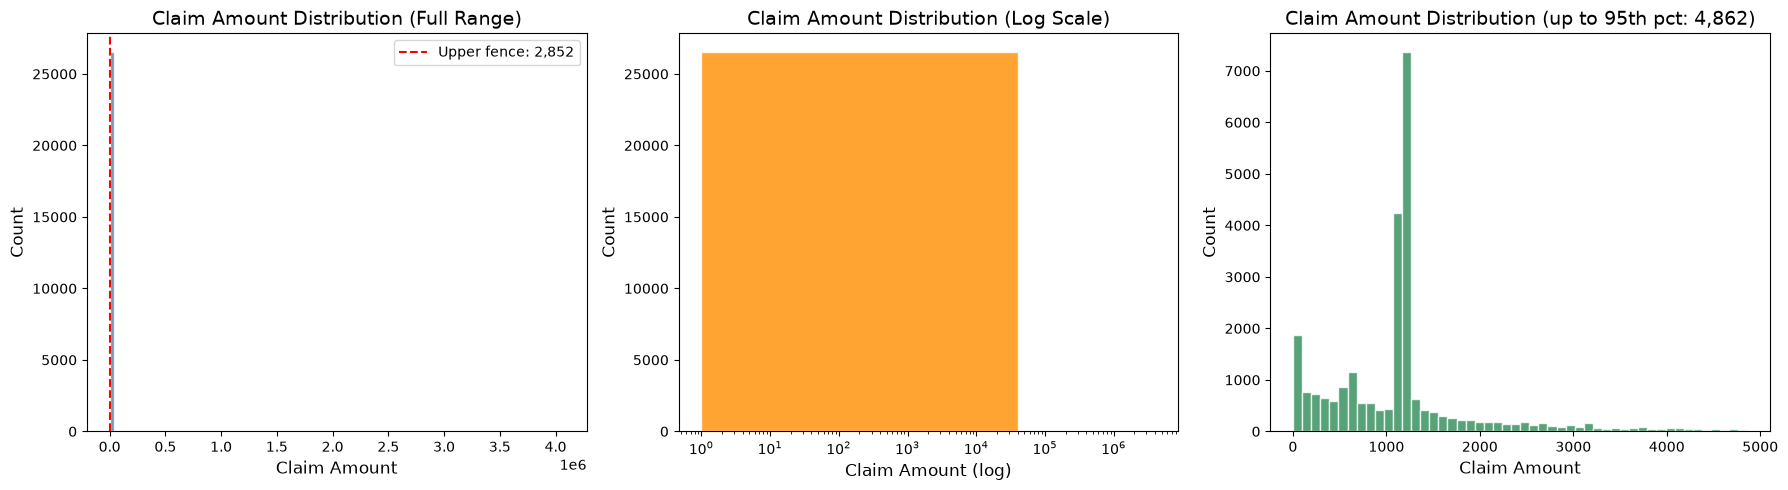

Figure saved: figures/q6_claim_distribution.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sev['ClaimAmount'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Claim Amount Distribution (Full Range)')
axes[0].set_xlabel('Claim Amount')
axes[0].set_ylabel('Count')
axes[0].axvline(x=upper_fence, color='red', linestyle='--', label=f'Upper fence: {upper_fence:,.0f}')
axes[0].legend()

axes[1].hist(sev['ClaimAmount'], bins=100, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_title('Claim Amount Distribution (Log Scale)')
axes[1].set_xlabel('Claim Amount (log)')
axes[1].set_ylabel('Count')

p95 = sev['ClaimAmount'].quantile(0.95)
axes[2].hist(sev[sev['ClaimAmount'] <= p95]['ClaimAmount'], bins=50,
             color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Claim Amount Distribution (up to 95th pct: {p95:,.0f})')
axes[2].set_xlabel('Claim Amount')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'q6_claim_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: figures/q6_claim_distribution.png')

---
## 10. Q7 — What should management monitor every month?

We design an **executive dashboard** with the most decision-useful KPIs and explain why each belongs on the dashboard.\n> **Note:** The charts below are matplotlib preview plots that serve as design> specifications for the actual Tableau dashboard. Build the final interactive> dashboard in Tableau Desktop/Public using the exported CSV files in `data/processed/`.

In [37]:
print("Q7: Executive Dashboard Design")
print("=" * 35)

print("\nPage 1: Portfolio Overview")
print(f"Policies: {policy_count:,}")
print(f"Exposure: {total_exposure:,.1f} years")
print(f"Claims: {total_claims:,}")
print(f"Claim frequency: {claim_frequency:.4f}")
print(f"Total claim cost: €{total_claim_cost:,.0f}")
print(f"Average claim severity: €{avg_severity:,.0f}")

print("\nCharts:")
print("- Claim frequency by region")
print("- Cost per exposure year by region")
print("- Regional KPI table")

print("\nPage 2: Claims and Risk Segments")
print("Charts:")
print("- Claim frequency by driver age")
print("- Claim frequency and severity by vehicle age")
print("- Frequency vs. severity by region")
print("- Region and driver age comparison")

print("\nPage 3: Claim Cost Analysis")
print("Charts:")
print("- Pareto chart of claim costs")
print("- Top individual claims")
print("- Total claim cost by region")
print("- Business recommendations")

print("\nFilters")
print("- Region")
print("- Vehicle age")
print("- Bonus-malus category")

print("\nDashboard features")
print("- Selecting a region filters the other charts")
print("- Tooltips show detailed KPIs")
print("- Filters can be cleared or changed")

Q7: Executive Dashboard Design

Page 1: Portfolio Overview
Policies: 678,013
Exposure: 358,499.4 years
Claims: 36,102
Claim frequency: 0.1007
Total claim cost: €59,909,216
Average claim severity: €2,249

Charts:
- Claim frequency by region
- Cost per exposure year by region
- Regional KPI table

Page 2: Claims and Risk Segments
Charts:
- Claim frequency by driver age
- Claim frequency and severity by vehicle age
- Frequency vs. severity by region
- Region and driver age comparison

Page 3: Claim Cost Analysis
Charts:
- Pareto chart of claim costs
- Top individual claims
- Total claim cost by region
- Business recommendations

Filters
- Region
- Vehicle age
- Bonus-malus category

Dashboard features
- Selecting a region filters the other charts
- Tooltips show detailed KPIs
- Filters can be cleared or changed


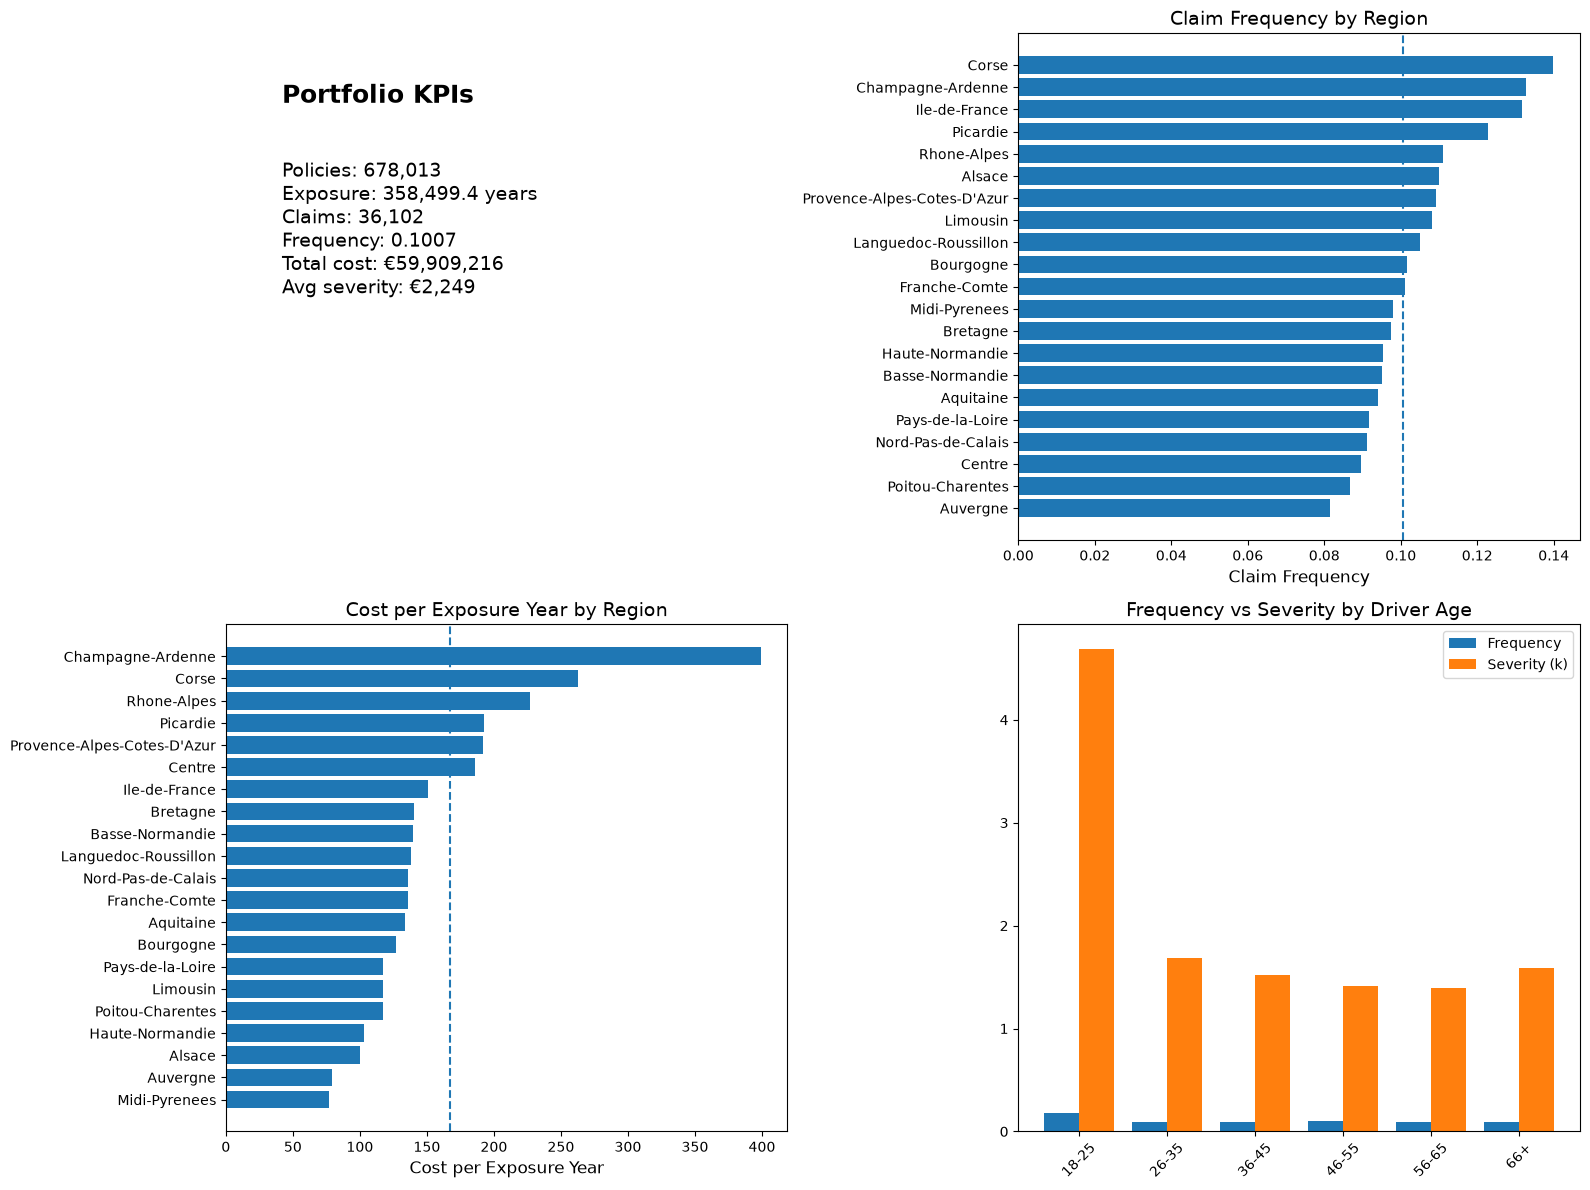

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].axis('off')
kpi_text = (
    f"Policies: {policy_count:,}\n"
    f"Exposure: {total_exposure:,.1f} years\n"
    f"Claims: {total_claims:,}\n"
    f"Frequency: {claim_frequency:.4f}\n"
    f"Total cost: €{total_claim_cost:,.0f}\n"
    f"Avg severity: €{avg_severity:,.0f}"
)
axes[0, 0].text(0.1, 0.9, "Portfolio KPIs", fontsize=18, fontweight='bold',
                va='top')
axes[0, 0].text(0.1, 0.75, kpi_text, fontsize=14, va='top')

region = region_kpi.sort_values('ClaimFrequency')
axes[0, 1].barh(region['Region'], region['ClaimFrequency'])
axes[0, 1].axvline(claim_frequency, linestyle='--')
axes[0, 1].set_title("Claim Frequency by Region")
axes[0, 1].set_xlabel("Claim Frequency")

region = region_kpi.sort_values('CostPerExposure')
axes[1, 0].barh(region['Region'], region['CostPerExposure'])
axes[1, 0].axvline(cost_per_exposure, linestyle='--')
axes[1, 0].set_title("Cost per Exposure Year by Region")
axes[1, 0].set_xlabel("Cost per Exposure Year")

age = age_kpi.sort_values('DrivAgeGroup')
x = np.arange(len(age))

axes[1, 1].bar(x - 0.2, age['ClaimFrequency'], 0.4, label='Frequency')
axes[1, 1].bar(x + 0.2, age['AvgSeverity'] / 1000, 0.4, label='Severity (k)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(age['DrivAgeGroup'], rotation=45)
axes[1, 1].set_title("Frequency vs Severity by Driver Age")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'q7_executive_dashboard_preview.png', dpi=150)
plt.show()

---
## 11. Q8 — Three Data-Driven Recommendations

Format: **Evidence -> Action -> KPI**

We must not imply causal effects that the data cannot establish.

In [36]:
print("Q8: Data-Driven Recommendations")
print("=" * 35)

top_cost_region = region_kpi.loc[region_kpi['CostPerExposure'].idxmax()]

print("\n1. Review high-cost regions")
print(f"Evidence: {top_cost_region['Region']} has the highest cost per exposure year "
      f"(€{top_cost_region['CostPerExposure']:,.0f}).")
print("Action: Review the risk and claim patterns in high-cost regions.")
print("KPI: Claim frequency and cost per exposure by region.")

young_driver = age_kpi[age_kpi['DrivAgeGroup'] == '18-25'].iloc[0]

print("\n2. Monitor young drivers")
print(f"Evidence: Drivers aged 18-25 have a claim frequency of "
      f"{young_driver['ClaimFrequency']:.4f}.")
print("Action: Monitor this segment and review its risk factors.")
print("KPI: Claim frequency for young drivers.")

top_10_cost = (
    claims.head(int(len(claims) * 0.10))['ClaimAmount'].sum()
    / claims['ClaimAmount'].sum() * 100
)

print("\n3. Focus on high-cost claims")
print(f"Evidence: The top 10% of claims account for about {top_10_cost:.0f}% "
      "of total claim cost.")
print("Action: Review unusually expensive claims.")
print("KPI: Number and total cost of high-cost claims.")

print("\nNote: These findings are descriptive and do not prove causation.")

Q8: Data-Driven Recommendations

1. Review high-cost regions
Evidence: Champagne-Ardenne has the highest cost per exposure year (€399).
Action: Review the risk and claim patterns in high-cost regions.
KPI: Claim frequency and cost per exposure by region.

2. Monitor young drivers
Evidence: Drivers aged 18-25 have a claim frequency of 0.1751.
Action: Monitor this segment and review its risk factors.
KPI: Claim frequency for young drivers.

3. Focus on high-cost claims
Evidence: The top 10% of claims account for about 60% of total claim cost.
Action: Review unusually expensive claims.
KPI: Number and total cost of high-cost claims.

Note: These findings are descriptive and do not prove causation.


In [35]:
print("Insurance Claims Project")
print("=" * 30)

print(f"Policies: {policy_count:,}")
print(f"Individual claims: {len(sev):,}")

print("\nKey KPIs")
print(f"Claim frequency: {claim_frequency:.4f}")
print(f"Average claim severity: €{avg_severity:,.0f}")
print(f"Total claim cost: €{total_claim_cost:,.0f}")

print("\nAnalysis completed")
print("Q1: Portfolio health")
print("Q2: Regional analysis")
print("Q3: Segment analysis")
print("Q4: Frequency vs severity")
print("Q5: Pareto analysis")
print("Q6: Outlier investigation")
print("Q7: Dashboard design")
print("Q8: Recommendations")

print("\nNext steps")
print("1. Build the dashboard in Tableau")
print("2. Add the final screenshots")
print("3. Update the README")
print("4. Finish the business summary")

Insurance Claims Project
Policies: 678,013
Individual claims: 26,639

Key KPIs
Claim frequency: 0.1007
Average claim severity: €2,249
Total claim cost: €59,909,216

Analysis completed
Q1: Portfolio health
Q2: Regional analysis
Q3: Segment analysis
Q4: Frequency vs severity
Q5: Pareto analysis
Q6: Outlier investigation
Q7: Dashboard design
Q8: Recommendations

Next steps
1. Build the dashboard in Tableau
2. Add the final screenshots
3. Update the README
4. Finish the business summary
